In [35]:
import cv2
import torch
import numpy as np

import matplotlib.pyplot as plt

# reference to cloned repository
from data.DeepFurniture.deepfurniture import DeepFurnitureDataset

# Data Preprocessing

Download data according to the hugging face descripton: https://huggingface.co/datasets/byliu/DeepFurniture#1-download-and-extraction

In [24]:
# Initialize dataset
dataset = DeepFurnitureDataset("./data/DeepFurniture/uncompressed_data")

print(f"Number of Scenes: {len(dataset)}")

Number of Scenes: 24182


## Depth Data

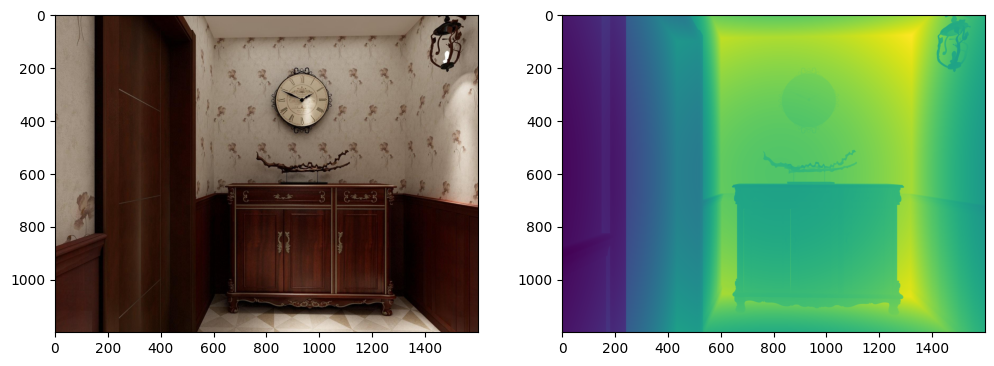

In [27]:
scene = dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(scene['image'])
axes[1].imshow(scene['depth'])

# MiDaS

In [30]:
model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
#model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
#model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

midas = torch.hub.load("intel-isl/MiDaS", model_type)

Using cache found in /Users/timon/.cache/torch/hub/intel-isl_MiDaS_master
/Users/timon/.pyenv/versions/dspro2/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [31]:
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f'selected device: {device}')
midas.to(device)
midas.eval()

selected device: mps


DPTDepthModel(
  (pretrained): Module(
    (model): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_featur

In [32]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in /Users/timon/.cache/torch/hub/intel-isl_MiDaS_master


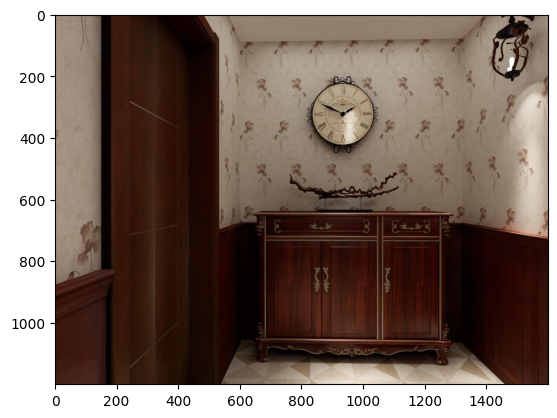

In [59]:
# For an I;16 mode image, you'll need to handle it appropriately
# Convert PIL image to numpy array
image = scene['image']

numpy_image = np.array(image)

# If you want to use it with OpenCV's display functions
# OpenCV uses BGR format while PIL uses RGB
# For I;16 mode, you might need to convert to a format cv2 can display well
if image.mode == 'I;16':
    # Convert to a more standard format
    pil_image_rgb = image.convert('RGB')
    numpy_image = np.array(pil_image_rgb)
    # Convert RGB to BGR (OpenCV format)
    img = cv2.cvtColor(numpy_image, cv2.COLOR_RGB2BGR)
else:
    # For regular RGB images
    img = cv2.cvtColor(numpy_image, cv2.COLOR_RGB2BGR)

    
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)

In [60]:
input_batch = transform(img).to(device)

In [61]:
with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()

Invert depth image to compare it with the depth image of the dataset

In [66]:
depth_type = output.dtype


if depth_type == np.uint8:
    max_value = 255
elif depth_type == np.uint16:
    max_value = 65535
else:
    # For float types, you might need to know the specific range
    # Or you can use the actual max value in the image
    max_value = np.max(output)

# Invert the image
inverted_depth = max_value - output

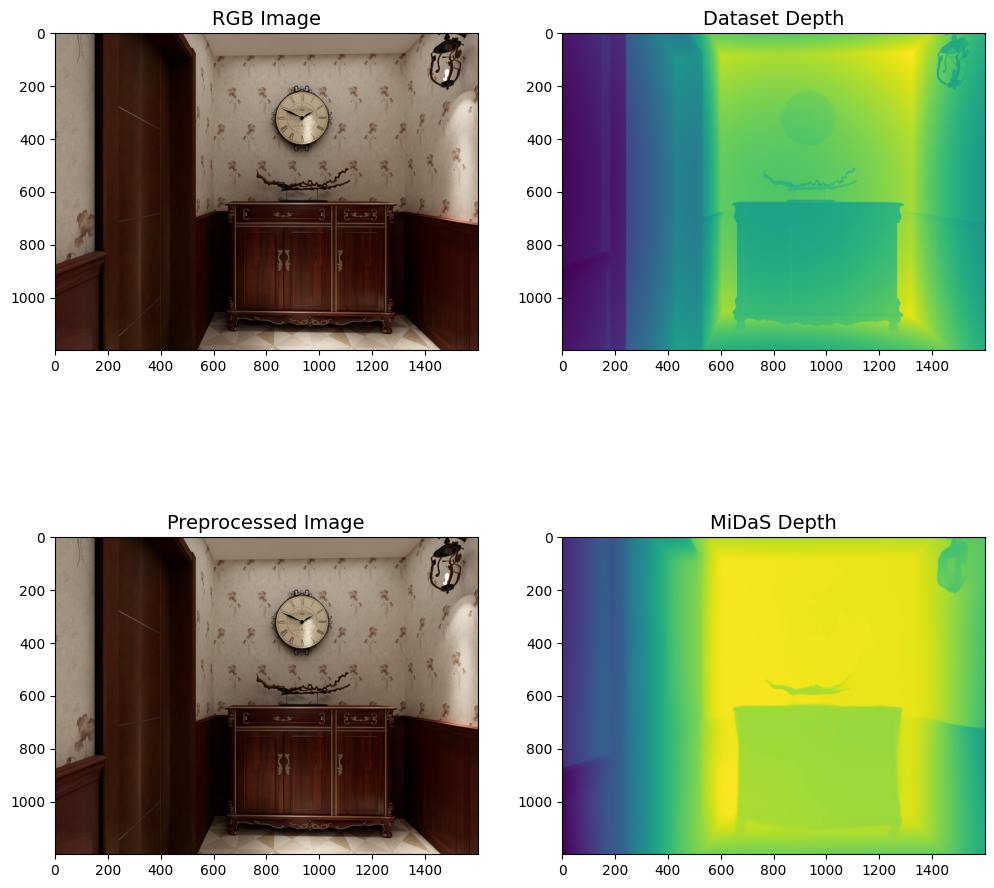

In [67]:
scene = dataset[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].set_title('RGB Image', fontsize=14)
axes[0, 0].imshow(scene['image'])

axes[0, 1].set_title('Dataset Depth', fontsize=14)
axes[0, 1].imshow(scene['depth'])

axes[1, 0].set_title('Preprocessed Image', fontsize=14)
axes[1, 0].imshow(img)

axes[1, 1].set_title('MiDaS Depth', fontsize=14)
axes[1, 1].imshow(inverted_depth)

# Model Evaluation